# Exercise 03 — Guide: Molecular dynamics with OpenMM

## Aim of the exercise

We will learn to:

- prepare a real PDB entry for simulation with **PDBFixer**
- set up and run a solvated simulation with **OpenMM**, step by step
- analyse the resulting trajectory with **MDAnalysis** (RMSD, radius of gyration, RMSF)
- read what a simulation does and does not tell you

Everything is worked on **one protein, 2JAC** (yeast glutaredoxin-1), from raw download to
per-residue flexibility — so you see one complete study rather than fragments of several.

Based on the official tutorials of
[OpenMM](https://github.com/openmm/openmm_workshop_july2023) and
[MDAnalysis](https://userguide.mdanalysis.org/stable/examples/quickstart.html).

**Exercise 03 is two notebooks:**

| Notebook | What it is |
|---|---|
| **`ex03_guide.ipynb`** (this one) | The full worked simulation of 2JAC. Every cell is filled in and explained. Nothing here is graded. |
| **`ex03_workbook.ipynb`** | The graded notebook. Open it once you have finished here. |

**No GPU required.** Measured on a plain CPU: minimisation ~30 s, and ~35 s per 10 ps of
MD for this ~20,000-atom solvated system. The "kernel will be restarted" note below is
just the pip-install session restart, nothing to do with GPUs.

<img src="openmm_logo.png" width="50"/>

# OpenMM

OpenMM is a versatile and high-performance toolkit designed for molecular simulation. It stands out due to its unique blend of features, which include extreme flexibility, openness, and exceptional performance, particularly on modern GPUs.

Summary of Contents:
1. **Setup Environment**: Instructions on preparing the necessary computational environment.
2. **Download Protein File**: Steps to obtain the required protein structure file.
3. **Load a PDB File into OpenMM**: Tutorial on how to import and use a PDB file within OpenMM.
4. **Choose the Force-Field**: Guidance on selecting appropriate force-fields for the simulation.
5. **Solvate the Protein with Water and Ions**: Process of adding water and ions to the protein environment.
6. **Setup System and Integrator**: Instructions on initializing the simulation system and integrator.
7. **Run Local Minimization**: Steps for performing local energy minimization of the system.
8. **Setup Reporting**: How to configure reporting tools for monitoring simulation progress.
9. **Run NVT Equilibration**: Conducting NVT (constant Number, Volume, Temperature) equilibration simulations.
10. **Run NPT Production Molecular Dynamics**: Executing NPT (constant Number, Pressure, Temperature) production simulations.
11. **Basic Analysis**: Introduction to fundamental analysis techniques for simulation data.
12. **How to Use Checkpoints**: Instructions on setting up and utilizing checkpoints for long-term simulations.
13. **Visualization**: Tips and tools for visualizing the simulation results.



## Setup

**A GPU is optional here, not required.** Measured on a plain Colab CPU runtime, the whole
2JAC workflow below takes roughly: minimisation ~30 s, NVT 10 ps ~33 s, NPT 10 ps ~36 s.
That is a couple of minutes for the complete simulation, which is well within a normal
session.

OpenMM *is* much faster on a GPU, and if you extend the run to hundreds of picoseconds
you will want one (Runtime → Change runtime type → GPU). For the guide as written, CPU is
the sensible default — Colab's GPU allocation is limited, and this exercise does not need
to spend it.

The note below about the kernel restarting is just the pip install; it has nothing to do
with GPUs.


In [1]:
if "google.colab" in str(get_ipython()):
    print("Running on colab")
    print("Installing required packages...")
    !pip install -q openmm==8.2.0 mdanalysis==2.10.0 py3dmol==2.4.0
    print("Installation complete!")
else:
    print("Not running on colab.")
    print("Make sure you have all required packages installed in your environment!")


Not running on colab.
Make sure you have all required packages installed in your environment!


**Note:** During this step on Colab the kernel will be restarted. This will produce the error message:
"Your session crashed for an unknown reason. " This is normal and you can safely ignore it.

**Note:** Installing the packages will take several minutes!

In [2]:
# check the installation
!python -m openmm.testInstallation

zsh:1: command not found: python


## Protein to study: 2JAC, yeast glutaredoxin-1

We simulate **2JAC** — the C30S mutant of yeast glutaredoxin-1, a real redox enzyme, and
the same protein you will analyse at the end of this notebook.

Two things make it a good teaching system. It is small (110 residues), so a full
solvated simulation finishes in minutes. And it is a **real, unmodified PDB entry** —
which means it is *not* ready to simulate as downloaded.

That last point is the lesson. A PDB file straight from the database routinely has
missing atoms, missing residues, no hydrogens, and heteroatoms the force field has never
heard of. Feeding one directly to OpenMM produces an error, not a simulation. The tool
for this is [PDBFixer](https://github.com/openmm/pdbfixer), and using it is the first
real step of any MD study — see also the
[OpenMM FAQs](https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions).

2JAC's crystal also contains its genuine cosubstrate, **glutathione (GSH)**. We remove
it, for an honest reason worth stating plainly: GSH is not one of the 20 standard amino
acids, and the Amber14 force field has **no parameters for it at all**. Building a system
that includes GSH with `amber14-all.xml` alone fails outright. Parametrising a small
molecule needs a dedicated small-molecule force field (GAFF2 or OpenFF) — that is Block D
territory, and you will meet it in ex04. So we simulate the **apo** protein and say so,
rather than quietly dropping a cofactor and pretending the result is the holo enzyme.

![2JAC](./2JAC.png)

**Figure.** Yeast glutaredoxin-1 (2JAC), coloured N-terminus (blue) to C-terminus (red).
The **yellow spheres** mark residue 30 — the catalytic cysteine, mutated to serine (C30S)
in this construct to make it crystallisable and catalytically dead. The **green sticks**
are the bound cosubstrate **glutathione (GSH)**, sitting in the active site right beside
it. GSH is what we remove before simulating, and you can see here exactly what is being
taken away — and how close to the catalytic position it sits.

Note the fold: a central β-sheet flanked by α-helices — the **thioredoxin fold**, one of
the most widespread architectures in biology. Keep the shape in mind; you will be asked at
the end which parts of it moved.


In [3]:
# 2JAC comes straight from the PDB, so we need PDBFixer to make it simulatable.
# Fetch with Python rather than wget, so this works identically on Colab, on a local
# conda environment, and in a container -- the download is not a Colab-only step.
import os
import urllib.request

if "google.colab" in str(get_ipython()):
    %pip install -q pdbfixer

if not os.path.exists("2JAC.pdb"):
    urllib.request.urlretrieve("https://files.rcsb.org/download/2JAC.pdb", "2JAC.pdb")
    print("Downloaded 2JAC.pdb from RCSB")
else:
    print("2JAC.pdb already present")


2JAC.pdb already present


### Preparing the structure

Each `fixer` call below addresses one specific defect. Read them as a checklist you will
repeat for your own protein:

| Call | What it fixes |
|---|---|
| `findMissingResidues()` | gaps in the chain the crystallographer could not resolve |
| `findNonstandardResidues()` | modified residues the force field will not recognise |
| `removeHeterogens(keepWater=False)` | ligands, ions and crystallographic waters — here, GSH |
| `findMissingAtoms()` / `addMissingAtoms()` | side-chain atoms absent from the density |
| `addMissingHydrogens(7.0)` | hydrogens, protonated for pH 7.0 — X-ray rarely sees them |

**Print what changed and check it.** A fixer that silently added 12 residues has made a
modelling decision on your behalf, and you are responsible for it either way.

In [4]:
from pdbfixer import PDBFixer
from openmm.app import PDBFile as _PDBFile

fixer = PDBFixer(filename="2JAC.pdb")
fixer.findMissingResidues()
fixer.findNonstandardResidues()
fixer.removeHeterogens(keepWater=False)   # strips GSH *and* crystallographic waters
fixer.findMissingAtoms()

print(f"Missing residues found: {len(fixer.missingResidues)}")
print(f"Missing atoms found   : {len(fixer.missingAtoms)}")
print(f"Nonstandard residues  : {fixer.nonstandardResidues}")

fixer.addMissingAtoms()
fixer.addMissingHydrogens(7.0)

with open("2JAC_fixed.pdb", "w") as f:
    _PDBFile.writeFile(fixer.topology, fixer.positions, f)

print(f"\nPrepared apo 2JAC: {fixer.topology.getNumAtoms()} atoms, "
      f"{fixer.topology.getNumResidues()} residues")

Missing residues found: 1


Missing atoms found   : 0
Nonstandard residues  : []



Prepared apo 2JAC: 1749 atoms, 110 residues


## Load the PDB file into OpenMM
<a id="load"></a>

First we need to import OpenMM.
We then then load in the PDB file using the [PDBFile](http://docs.openmm.org/latest/api-python/generated/openmm.app.pdbfile.PDBFile.html#openmm.app.pdbfile.PDBFile) class.

In [5]:
from openmm.app import (
    ForceField,
    Modeller,
    HBonds,
    Simulation,
    DCDReporter,
    StateDataReporter,
    PME,
    PDBFile,
    CheckpointReporter,
)
from openmm import LangevinMiddleIntegrator, MonteCarloBarostat, XmlSerializer
from openmm.unit import kelvin, nanometer, picosecond, picoseconds, bar, seconds
from sys import stdout

# Load the PREPARED structure -- never the raw download.
pdb = PDBFile("2JAC_fixed.pdb")
print(f"Loaded {pdb.topology.getNumAtoms()} atoms, {pdb.topology.getNumResidues()} residues")

Loaded 1749 atoms, 110 residues


`PDBFile('file_name.pdb')` loads the PDB file from disk and puts the information into a `PDBFile` object which we have assign to the variable `pdb`. The object contains the molecular topology (atom names, residue types, bonds etc) and the atomic positions. These can be accessed as `pdb.topology` and `pdb.positions`. Take a look at the [API documentation](http://docs.openmm.org/latest/api-python/generated/openmm.app.pdbfile.PDBFile.html#openmm.app.pdbfile.PDBFile). All OpenMM classes have documentation available on the Python API reference: http://docs.openmm.org/latest/api-python/.

## Define the force field
<a id="ff"></a>

We need to define the forcefield we want to use. We will use the Amber14 forcefield and the TIP3P-FB water model. You can find out about all the forcefields available by default in OpenMM in the [documentation](http://docs.openmm.org/latest/userguide/application/02_running_sims.html?highlight=forcefield#force-fields).

In [6]:
# Specify the forcefield
forcefield = ForceField("amber14-all.xml", "amber14/tip3pfb.xml")

Force fields are defined by XML files. The line above loads in specified files. You can look at them in the OpenMM source code, e.g. [`amber14/tip3pfb.xml`](https://github.com/openmm/openmm/blob/master/wrappers/python/openmm/app/data/amber14/tip3pfb.xml). It is possible to create your own XML force field file. You can find details in the [user guide](http://docs.openmm.org/latest/userguide/application/05_creating_ffs.html#creating-force-fields).

## Solvate
<a id="solvate"></a>

We can use the [`Modeller`](http://docs.openmm.org/latest/userguide/application/03_model_building_editing.html#model-building-and-editing) class to solvate the protein in a waterbox. 

In [7]:
# create a Modeller object
modeller = Modeller(pdb.topology, pdb.positions)


# Solvate the protein in a box of water
modeller.addSolvent(forcefield, padding=1.0 * nanometer)

This command creates a box that has edges at least 1nm away from the solute and fills it with water molecules. Additionally, it adds in the required number of CL- and Na+ ions to make the system charge neutral. Optionally, you can specify the ion concentration as an argument to [`addSolvent`](http://docs.openmm.org/latest/api-python/generated/openmm.app.modeller.Modeller.html#openmm.app.modeller.Modeller.addSolvent). 

Note that the `nanometer` variable is a unit definition that was imported from `openmm.unit`. This is an example of the powerful units tracking and automatic conversion facility built into the OpenMM Python API that makes specifying unit-bearing quantities convenient and less error-prone. We could have equivalently specified `10*angstrom` instead of `1*nanometer` and achieved the same result. You can read more about the units library [here](http://docs.openmm.org/latest/userguide/library/05_languages_not_cpp.html#units-and-dimensional-analysis).


## Setup system and Integrator
<a id='system'></a>

We now need to combine our molecular topology and the forcefield to create a complete description of the system. This is done using the [`ForceField`](http://docs.openmm.org/latest/api-python/generated/openmm.app.forcefield.ForceField.html#forcefield) object’s [`createSystem()`](http://docs.openmm.org/latest/api-python/generated/openmm.app.forcefield.ForceField.html#openmm.app.forcefield.ForceField.createSystem) method. We then create the integrator, and combine the integrator and system to create the Simulation object. Finally we set the initial atomic positions.

In [8]:
# Create a system. Here we define some forcefield settings such as the nonbonded method
system = forcefield.createSystem(
    modeller.topology,
    nonbondedMethod=PME,
    nonbondedCutoff=1.0 * nanometer,
    constraints=HBonds,
)

# Define the integrator. The Langevin integrator is also a thermostat
integrator = LangevinMiddleIntegrator(300 * kelvin, 1 / picosecond, 0.004 * picoseconds)

# Create the Simulation
simulation = Simulation(modeller.topology, system, integrator)
simulation.context.setPositions(modeller.positions)

The [System](http://docs.openmm.org/latest/api-python/generated/openmm.openmm.System.html#system) is an object than contains the complete mathematical description of the system we want to simulate. It contains four key bits of information:
 - The set of particles in the simulation
 - The forces acting on them
 - Details of any constraints
 - The dimensions of the periodic box

The `integrator` advances the equations of motion. There are a variety of [integrators available in OpenMM](http://docs.openmm.org/latest/api-python/library.html#integrators). We are using the [LangevinMiddleIntegrator](http://docs.openmm.org/latest/api-python/generated/openmm.openmm.LangevinMiddleIntegrator.html#openmm.openmm.LangevinMiddleIntegrator) which performs Langevin dynamics.

The [`Simulation`](http://docs.openmm.org/latest/api-python/generated/openmm.app.simulation.Simulation.html#openmm.app.simulation.Simulation) object manages all the process involved in running a simulation, such as advancing time and writing output. 


## Local energy minimization
<a id="minim"></a>

It is a good idea to run local energy minimization at the start of a simulation because the coordinates in starting configuration file might produce very large forces. 

Due to how the minimizer is implemented it will not print out information during the run. You will need to be patient and wait for it to complete. This minimization step should take ~1 minute on CPU and a few seconds on GPU.

In [9]:
print("Minimizing energy")
simulation.minimizeEnergy()

Minimizing energy


## Setup reporting
<a id="reporting"></a>

To get output from a simulation you need to add "reporters". We use [`DCDReporter`](http://docs.openmm.org/latest/api-python/generated/openmm.app.dcdreporter.DCDReporter.html) to write the coordinates every 1000 timesteps to 'traj.dcd' and we use [`StateDataReporter`](http://docs.openmm.org/development/api-python/generated/openmm.app.statedatareporter.StateDataReporter.html) to print the timestep, potential energy, temperature, and volume to the screen; and the same to a file called 'md_log.txt'. The Simulation object contains a list of reporters in `simulation.reporters` and we use the append method to add the reporters to it.

In [10]:
# Write trajectory to a file called traj.dcd every 1000 steps
simulation.reporters.append(DCDReporter("traj.dcd", 1000))

# Print state information to the screen every 1000 steps
simulation.reporters.append(
    StateDataReporter(
        stdout, 1000, step=True, potentialEnergy=True, temperature=True, volume=True
    )
)

# Print the same info to a log file every 100 steps
simulation.reporters.append(
    StateDataReporter(
        "md_log.txt",
        100,
        step=True,
        potentialEnergy=True,
        temperature=True,
        volume=True,
    )
)


## NVT equilibration
<a id=nvt></a>

We are using a Langevin integrator which means we are simulating in the NVT ensemble. To equilibrate the temperature we just need to run the simulation for a number of timesteps.

In [11]:
print("Running NVT")
simulation.step(1000)

Running NVT


#"Step","Potential Energy (kJ/mole)","Temperature (K)","Box Volume (nm^3)"


1000,-321585.4877557783,292.11721024962634,213.7130788709624


## NPT production MD
<a id=npt></a>

To run our simulation in the NPT ensemble we need to add in a barostat to control the pressure. We can use [`MonteCarloBarostat`](http://docs.openmm.org/latest/api-python/generated/openmm.openmm.MonteCarloBarostat.html#openmm.openmm.MonteCarloBarostat). The parameters are the pressure (1 bar) and the temperature (300 K). The barostat assumes the simulation is being run at constant temperature, but it does not itself do anything to regulate the temperature. It is therefore critical that you always use it along with a Langevin integrator or Andersen thermostat, and that you specify the same temperature for both the barostat and the integrator or thermostat. Otherwise, you will get incorrect results.

In [12]:
system.addForce(MonteCarloBarostat(1 * bar, 300 * kelvin))

# It is important to call the reinitialize method on the simulation
# otherwise the modifications will not be applied.
simulation.context.reinitialize(preserveState=True)

We then run the simulation for 10000 steps.

In [13]:
print("Running NPT")
simulation.step(10000)

Running NPT


2000,-318848.39218536386,299.9481628675177,205.39194809484042


3000,-320626.3868143156,298.7032252996111,202.86035172727952


4000,-322028.4011578307,294.8341083042355,201.77572607795315


5000,-321230.34470906854,300.2553276297536,200.9080101531201


...

7000,-319667.3367049609,301.2756551726291,200.62447804063635


8000,-320348.34811607306,302.9274805629058,200.98239696517373


9000,-321673.6937404714,300.1245504010138,201.0607328417927


10000,-321024.5117789719,298.86158604911054,202.0658537995148


11000,-320659.0885235796,300.69751905073235,201.8491660968694


## Analysis
<a id=analysis></a>

We can now do some basic analysis using Python. We will plot the time evolution of the potential energy, temperature, and box volume. Remember that OpenMM itself is primarily an MD engine, for in-depth analysis of your simulations you can use other python packages such as [MDtraj](https://www.mdtraj.org/), or [MDAnalysis](https://www.mdanalysis.org/).


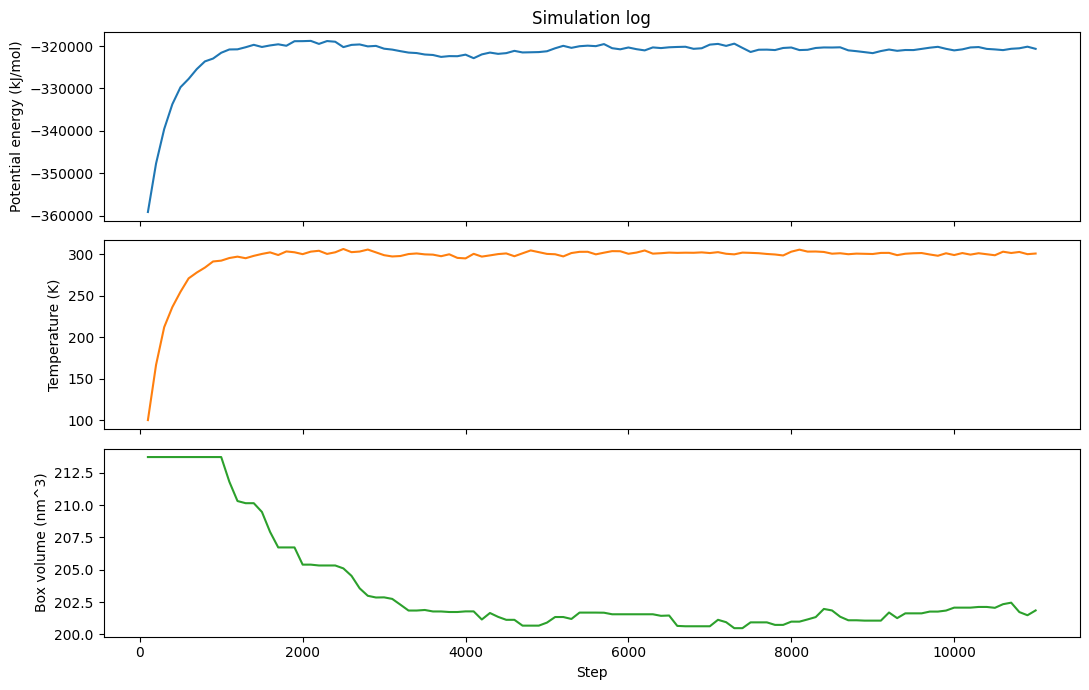

,Step,Potential Energy (kJ/mole),Temperature (K),Box Volume (nm^3)
count,110.00,110.00,110.00,110.00
mean,5550.00,-321767.70,295.03,203.45
std,3189.83,5099.40,25.58,3.97
min,100.00,-359086.23,99.90,200.48
25%,2825.00,-321418.29,298.79,201.15
50%,5550.00,-320674.44,300.47,201.73
75%,8275.00,-320225.95,301.86,202.95
max,11000.00,-318789.00,306.19,213.71


In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# pandas plots through matplotlib by default. `subplots=True` turns one call into a
# stacked panel per column -- the whole three-panel figure below is one statement.
md_log_df = pd.read_csv("md_log.txt", delimiter=",", header=0)
md_log_df.rename(columns={'#"Step"': "Step"}, inplace=True)

axes = (
    md_log_df.set_index("Step")[
        ["Potential Energy (kJ/mole)", "Temperature (K)", "Box Volume (nm^3)"]
    ]
    .plot(subplots=True, figsize=(11, 7), legend=False, sharex=True)
)
for ax, label in zip(axes, ["Potential energy (kJ/mol)", "Temperature (K)", "Box volume (nm^3)"]):
    ax.set_ylabel(label)
axes[0].set_title("Simulation log")
axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

md_log_df.describe().round(2)

## Checkpointing
<a id=checkpoints></a>

When you run long simulations it is useful to be able to save checkpoints. This means you can restart them in the case of a crash. Or it means you can resume them if you need to fit within the time constraints of a HPC job scheduler.

To run a resume a simulation we need to have three files saved to disk that we can load in:
1. The topology - this will be a PDB file of our solvated system.
2. A serialized `System` -  this is an xml file that contains the forcefield settings.
3. A checkpoint file - this is a binary file that contains the positions, velocities, box vectors, and other internal data such as the states of random number generators.

The first two only need to be saved once because they are constant throughout the simulation. The checkpoint file needs to be saved frequently. You can then resume a simulation from the timestep when the checkpoint file was last saved.


### Setup the checkpoint

We will create the topology file using `PDBFile` to write a PDB file of the system. We will use `XmlSerializer` of save the serialized system to an xml file. And we will use `CheckpointReporter` to regularly create checkpoint files.

In [15]:
# Save the toplogy as a PDB file.
with open("topology.pdb", "w") as output:
    PDBFile.writeFile(
        simulation.topology,
        simulation.context.getState(getPositions=True).getPositions(),
        output,
    )

# save a serialized version of the system. This stores the forcefield parameters.
with open("system.xml", "w") as output:
    output.write(XmlSerializer.serialize(system))

# Setup a checkpoint reporter. This stores the positions, velocities, and box vectors. It will save
# a checkpoint every 1000 timesteps.
simulation.reporters.append(CheckpointReporter("checkpoint.chk", 1000))


In [16]:
import py3Dmol

# Visualize the initial snapshot (topology.pdb) - Full system
print("Initial Structure (Full System - Protein + Water + Ions):")
view = py3Dmol.view(width=800, height=500)
with open("topology.pdb") as f:
    pdb_data = f.read()
    view.addModel(pdb_data, "pdb")

# Style: Protein as cartoon, water/ions as spheres
view.setStyle({"model": 0}, {"cartoon": {"color": "spectrum"}})
view.addStyle({"resn": "HOH"}, {"sphere": {"radius": 0.4}})
view.addStyle({"resn": ["NA", "CL"]}, {"sphere": {"radius": 1, "color": "yellow"}})
view.zoomTo()
view.show()

Initial Structure (Full System - Protein + Water + Ions):


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Visualize the initial structure

We can use `py3Dmol` to visualize the initial structure (topology.pdb) directly in the notebook.

`CheckpointReporter` saves periodic checkpoints of a simulation. The checkpoints will overwrite one another - only the last checkpoint will be saved in the file. Loading a checkpoint will restore a simulation to a reasonably close, but usually not identical, state to when it was written. The checkpoint contains data that is highly specific to the System, Platform, and the hardware and software of the computer it was created on. If you try and load it on a computer with different hardware it is likely to fail. Checkpoints created with different versions of OpenMM are often incompatible. 

For a more portable way of saving the state of a simulation you can save the checkpoint as an xml state file. Read the [API docs](http://docs.openmm.org/development/api-python/generated/openmm.app.checkpointreporter.CheckpointReporter.html) for more information.

### Running for a set time limit

We can run for a set amount of wall-clock time using the [`runForClockTime`](http://docs.openmm.org/latest/api-python/generated/openmm.app.simulation.Simulation.html#openmm.app.simulation.Simulation.runForClockTime) method. By [wall-clock](https://en.wikipedia.org/wiki/Elapsed_real_time) time we mean the actual time a program runs for as measured by looking at a clock on a wall (or a watch, or a timer etc) as opposed to the simulated time.


In [17]:
# run for 30 seconds
simulation.runForClockTime(30.0 * seconds)

12000,-320354.1786625207,301.3376321348948,201.8101869183157


13000,-321625.8077449101,299.09957276197326,200.93316055581892


14000,-321694.53500472975,299.3248041931107,201.58750234413628


### Resume from a checkpoint

We now have the required files 'topology.pdb', 'system.xml', and 'checkpoint.chk'. We will need to load them in so we can resume the simulation from the last checkpoint. Note that we have to define the integrator again as well as the simulation reporters. Furthermore, we have set the `append=True` flag to the DCD and StateData reporters.

You will need to add a line of code to make the simulation run for 30 seconds of wall time.

In [18]:
pdb = PDBFile("topology.pdb")

with open("system.xml") as input:
    system = XmlSerializer.deserialize(input.read())

# Define the integrator.
integrator = LangevinMiddleIntegrator(300 * kelvin, 1 / picosecond, 0.004 * picoseconds)

# Create the Simulation
simulation = Simulation(pdb.topology, system, integrator)

# set the positions, velocities, and box vectors from the checkpoint file
simulation.loadCheckpoint("checkpoint.chk")

# We still need to define the reporters again

# Write trajectory to a file called traj.dcd every 1000 steps
simulation.reporters.append(DCDReporter("traj.dcd", 1000, append=True))

# Print state information to the screen every 1000 steps
simulation.reporters.append(
    StateDataReporter(
        stdout, 1000, step=True, potentialEnergy=True, temperature=True, volume=True
    )
)

# Print the same info to a log file every 100 steps
simulation.reporters.append(
    StateDataReporter(
        "md_log.txt",
        100,
        step=True,
        potentialEnergy=True,
        temperature=True,
        volume=True,
        append=True,
    )
)


# Setup a checkpoint reporter. This stores the positions, velocities, and box vectors.
simulation.reporters.append(CheckpointReporter("checkpoint.chk", 1000))


# write the code to run for 30 seconds of wall clock time
simulation.runForClockTime(30.0 * seconds)


#"Step","Potential Energy (kJ/mole)","Temperature (K)","Box Volume (nm^3)"


15000,-321431.7969800325,299.91217296260726,201.0904636837993


16000,-320845.90451889264,303.95509748055235,201.261863239736


17000,-320356.89028462523,302.7168995788098,201.51169166309788


### Resume multiple times

We can practice resuming multiple times. This is something you might have to do to fit a long simulation within the limits of a HPC job scheduler.

You will need to add the code to create the `Simulation` object.

In [19]:
for i in range(3):
    print("Resuming from checkpoint iteration = ", i)

    pdb = PDBFile("topology.pdb")

    with open("system.xml") as input:
        system = XmlSerializer.deserialize(input.read())

    # Define the integrator.
    integrator = LangevinMiddleIntegrator(
        300 * kelvin, 1 / picosecond, 0.004 * picoseconds
    )

    # Create the Simulation
    # write the code to create the simulation object
    simulation = Simulation(pdb.topology, system, integrator)

    # set the positions, velocities, and box vectors from the checkpoint file
    simulation.loadCheckpoint("checkpoint.chk")

    # We still need to define the reporters again

    # Write trajectory to a file called traj.dcd every 1000 steps
    simulation.reporters.append(DCDReporter("traj.dcd", 1000, append=True))

    # Print state information to the screen every 1000 steps
    simulation.reporters.append(
        StateDataReporter(
            stdout, 1000, step=True, potentialEnergy=True, temperature=True, volume=True
        )
    )

    # Print the same info to a log file every 100 steps
    simulation.reporters.append(
        StateDataReporter(
            "md_log.txt",
            100,
            step=True,
            potentialEnergy=True,
            temperature=True,
            volume=True,
            append=True,
        )
    )

    # Setup a checkpoint reporter. This stores the positions, velocities, and box vectors.
    simulation.reporters.append(CheckpointReporter("checkpoint.chk", 1000))

    # run for 30 seconds
    simulation.runForClockTime(30.0 * seconds)


Resuming from checkpoint iteration =  0


#"Step","Potential Energy (kJ/mole)","Temperature (K)","Box Volume (nm^3)"


18000,-321156.62429312966,301.2718951971479,201.19939591842203


19000,-321572.73366426746,297.33846399515176,201.4730583567156


20000,-321563.3160027815,301.3354320191341,201.3043765049326


...

Resuming from checkpoint iteration =  2


#"Step","Potential Energy (kJ/mole)","Temperature (K)","Box Volume (nm^3)"


24000,-321197.0758511844,299.793774965488,200.35009326484516


25000,-320591.8188290872,297.248336216318,200.7187959426716


26000,-321533.45110477373,301.831713726046,200.908214167464


### Analysis

we can redo the analysis on the longer trajectory.

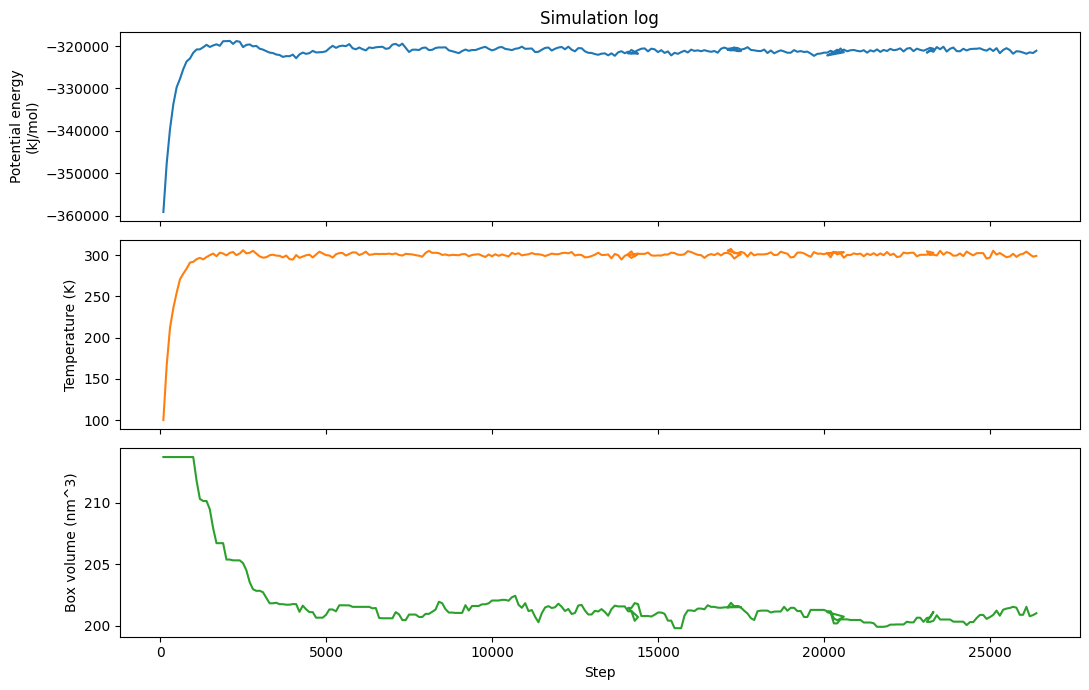

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

md_log_df = pd.read_csv("md_log.txt", delimiter=",", header=0)
md_log_df.rename(columns={'#"Step"': "Step"}, inplace=True)

# One call, three stacked panels: pandas plots each column into its own axis.
axes = (
    md_log_df.set_index("Step")[
        ["Potential Energy (kJ/mole)", "Temperature (K)", "Box Volume (nm^3)"]
    ]
    .plot(subplots=True, figsize=(11, 7), legend=False, sharex=True)
)
for ax, label in zip(axes, ["Potential energy\n(kJ/mol)", "Temperature (K)", "Box volume (nm^3)"]):
    ax.set_ylabel(label)
axes[0].set_title("Simulation log")
axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()


# MDAnalysis 

[MDAnalysis](https://www.mdanalysis.org/) is a Python library for analyzing molecular dynamics (MD) simulations. It supports various MD formats for reading and writing trajectories and atom selections. Key features include reading particle-based trajectories, accessing atomic coordinates via NumPy arrays, powerful atom selection commands, and the ability to manipulate and write out trajectories. This makes it a flexible and efficient tool for complex MD analysis tasks.


In [21]:
import MDAnalysis as mda

MDAnalysis is a Python package for accessing and analyzing molecular dynamics trajectory data. Its core data structures include:

- **Atom**: Represents a particle, even if it's a coarse-grained bead.
- **AtomGroup**: A crucial class where atoms are grouped. Most data can be accessed through AtomGroups.
- **Universe**: Combines all particles in an AtomGroup with a trajectory, providing access to the entire molecular system.

Working with MDAnalysis typically starts with loading data into a `Universe`.

In [22]:
# loading a trajectory
u = mda.Universe("topology.pdb", "traj.dcd")
u

/home/yerko/Development/structural-bioinformatics-lectures/exercises/.venv/lib/python3.13/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


<Universe with 20334 atoms>

In [23]:
# Go to the last frame of the trajectory
u.trajectory[-1]

# Write the last frame to a PDB file
with mda.Writer("last_frame.pdb", u.atoms.n_atoms) as writer:
    writer.write(u.atoms)

# Visualize the last frame using py3Dmol
print("Last Frame (Full System - Protein + Water + Ions):")
view = py3Dmol.view(width=800, height=500)
with open("last_frame.pdb") as f:
    pdb_data = f.read()
    view.addModel(pdb_data, "pdb")

# Style: Protein as cartoon, water/ions as spheres
view.setStyle({"model": 0}, {"cartoon": {"color": "spectrum"}})
view.addStyle({"resn": "HOH"}, {"sphere": {"radius": 0.4}})
view.addStyle({"resn": ["NA", "CL"]}, {"sphere": {"radius": 1, "color": "yellow"}})
view.zoomTo()
view.show()

Last Frame (Full System - Protein + Water + Ions):


/home/yerko/Development/structural-bioinformatics-lectures/exercises/.venv/lib/python3.13/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Visualize the last frame

We can extract the last frame from the trajectory and visualize it using `py3Dmol`.

The trajectory of the simulation is saved in the `u.trajectory` attribute. It is an iterator that yields a `Timestep` object for each frame in the trajectory. The `Timestep` object contains the coordinates of all atoms in the simulation at a given time step. The `Timestep` object also contains the simulation box dimensions, the simulation time, and the simulation step.

In [24]:
# Get the number of frames in the trajectory
len(u.trajectory)

26

Get the number of residues and atoms in the protein

In [25]:
u.residues, u.atoms

(<ResidueGroup with 6309 residues>, <AtomGroup with 20334 atoms>)

MDAnalysis has powerful selection tools that allow you to select atoms based on their properties. For example:

In [26]:
# Select the first 5 residues of the protein
print(u.select_atoms("resid 1:5").residues)
# Select the residues that are within 5 angstroms of the first residue
print(u.select_atoms("around 5 resid 1").residues)
# Selec the PHE residues
print(u.select_atoms("resname PHE").residues)

<ResidueGroup [<Residue MET, 1>, <Residue VAL, 2>, <Residue SER, 3>, <Residue GLN, 4>, <Residue GLU, 5>, <Residue HOH, 1>, <Residue HOH, 2>, <Residue HOH, 3>, <Residue HOH, 4>, <Residue HOH, 5>]>
<ResidueGroup [<Residue VAL, 2>, <Residue SER, 3>, <Residue GLN, 4>, ..., <Residue HOH, 6117>, <Residue HOH, 6129>, <Residue HOH, 6179>]>
<ResidueGroup [<Residue PHE, 20>, <Residue PHE, 38>]>


For the `Universe` object, water molecules are considered as residues. To select only the protein, you can use the `protein` keyword.

In [27]:
# Select the protein
protein = u.select_atoms("protein")

In [28]:
type(protein)

MDAnalysis.core.groups.AtomGroup

`AtomGroups` are the core data structure in MDAnalysis. You can get the positions of the atoms in an `AtomGroup` as a numpy array, as well as other properties such as the atom names, residue names, residue numbers, and residue IDs.

In [29]:
protein.positions

array([[23.381891 , 47.966652 , 19.951542 ],
       [22.954823 , 48.693985 , 20.507143 ],
       [23.255402 , 47.014854 , 20.264894 ],
       ...,
       [ 7.9092326, 17.925459 , -8.486598 ],
       [ 8.705146 , 18.805283 , -8.09918  ],
       [ 8.2776985, 16.707853 , -8.4488735]], dtype=float32)

In [30]:
print("Center of Mass:", protein.center_of_mass())
print("Center of Geometry:", protein.center_of_geometry())
print("Total Mass:", protein.total_mass())
print("Radius of Gyration:", protein.radius_of_gyration())

Center of Mass: [12.02084018 30.36097315  8.89392226]
Center of Geometry: [12.12331357 30.3270615   8.85503152]
Total Mass: 12358.109999999997
Radius of Gyration: 13.92064224830834


## Working with trajectories

The trajectory of a Universe contains the changing coordinate information. 
The standard way to assess the information of each frame in a trajectory is to iterate over it. When the timestep changes, the universe only contains information associated with that timestep.



In [31]:
for ts in u.trajectory:
    time = u.trajectory.time
    rgyr = protein.radius_of_gyration()
    print(f"Frame: {ts.frame:3d}, Time: {time:4.0f} ps, Rgyr: {rgyr:.4f} A")

Frame:   0, Time:    4 ps, Rgyr: 14.1969 A
Frame:   1, Time:    8 ps, Rgyr: 13.9100 A
Frame:   2, Time:   12 ps, Rgyr: 14.0395 A
Frame:   3, Time:   16 ps, Rgyr: 13.9621 A
Frame:   4, Time:   20 ps, Rgyr: 13.9219 A
Frame:   5, Time:   24 ps, Rgyr: 13.9009 A
Frame:   6, Time:   28 ps, Rgyr: 14.0025 A
Frame:   7, Time:   32 ps, Rgyr: 13.9338 A
Frame:   8, Time:   36 ps, Rgyr: 13.8934 A
Frame:   9, Time:   40 ps, Rgyr: 13.9568 A
Frame:  10, Time:   44 ps, Rgyr: 13.8949 A
Frame:  11, Time:   48 ps, Rgyr: 13.9590 A
Frame:  12, Time:   52 ps, Rgyr: 13.8605 A
Frame:  13, Time:   56 ps, Rgyr: 13.9365 A
Frame:  14, Time:   60 ps, Rgyr: 13.9555 A
Frame:  15, Time:   64 ps, Rgyr: 13.9449 A
Frame:  16, Time:   68 ps, Rgyr: 13.9138 A
Frame:  17, Time:   72 ps, Rgyr: 13.9212 A
Frame:  18, Time:   76 ps, Rgyr: 13.8720 A
Frame:  19, Time:   80 ps, Rgyr: 13.9841 A
Frame:  20, Time:   84 ps, Rgyr: 13.9409 A
Frame:  21, Time:   88 ps, Rgyr: 13.8990 A
Frame:  22, Time:   92 ps, Rgyr: 13.9450 A
Frame:  23,

In order to collect the radius of gyration, we can iterate over the trajectory and store the information in a list.
This can then be converted into other data structures, such as a numpy array or a pandas DataFrame. It can be plotted (as below), or used for further analysis.

In [32]:
import pandas as pd

rgyr = []
time = []
protein = u.select_atoms("protein")
for ts in u.trajectory:
    time.append(u.trajectory.time)
    rgyr.append(protein.radius_of_gyration())

rgyr_df = pd.DataFrame(rgyr, columns=["Radius of gyration (A)"], index=time)
rgyr_df.index.name = "Time (ps)"
rgyr_df

,Radius of gyration (A)
Time (ps),
4.0,14.196881
8.0,13.910042
12.0,14.039524
16.0,13.962105
20.0,13.921869
24.0,13.900909
28.0,14.002461
32.0,13.933834
36.0,13.893415


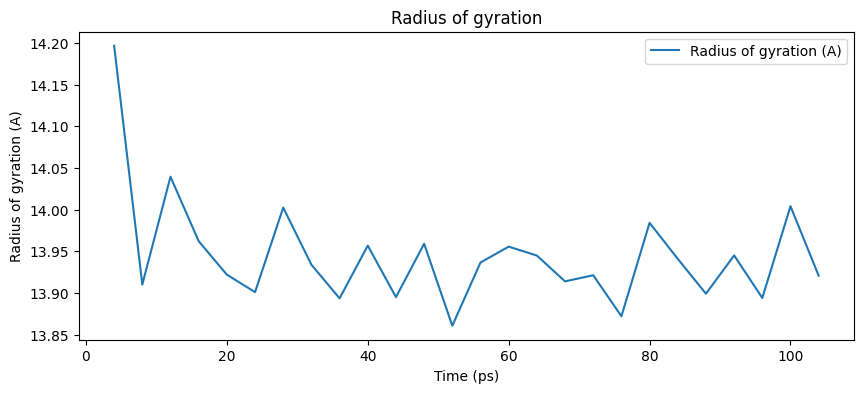

In [33]:
# pandas -> matplotlib: `.plot()` returns an Axes we can label directly.
ax = rgyr_df.plot(figsize=(10, 4), title="Radius of gyration")
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Radius of gyration (A)")
plt.show()

RMSD is a common metric for assessing the similarity of two structures.

In [34]:
from MDAnalysis.analysis import rms

bb = u.select_atoms("backbone")

u.trajectory[0]  # first frame
first = bb.positions

u.trajectory[-1]  # last frame
last = bb.positions

rms.rmsd(first, last)

np.float64(2.1689731429395476)

In the trajectory analysis, we can calculate the RMSD of each frame to the first frame.

In [35]:
u.trajectory[0]  # set to first frame
rmsd_analysis = rms.RMSD(u, select="backbone", groupselections=["name CA", "protein"])
rmsd_analysis.run()

In [36]:
rmsd_analysis.results.rmsd.shape

(26, 5)

We can interpret this as an array with 30 rows and 5 columns. Each row is the RMSD associated with a frame in the trajectory. The columns are as follows:

1. Frame number
2. Time (ps)
3. RMSD (backbone)
4. RMSD (C-alpha)
5. RMSD (protein)

In [37]:
import pandas as pd

rmsd_df = pd.DataFrame(
    rmsd_analysis.results.rmsd[:, 2:],
    columns=["Backbone", "C-alphas", "Protein"],
    index=rmsd_analysis.results.rmsd[:, 1],
)
rmsd_df.index.name = "Time (ps)"
rmsd_df.head()

,Backbone,C-alphas,Protein
Time (ps),,,
4.0,5.750873e-07,2.120649e-07,2.204238e-07
8.0,7.449241e-01,7.312457e-01,1.019914e+00
12.0,8.478473e-01,8.097741e-01,1.146385e+00
16.0,9.177073e-01,8.969367e-01,1.223680e+00
20.0,9.282097e-01,9.058707e-01,1.282626e+00


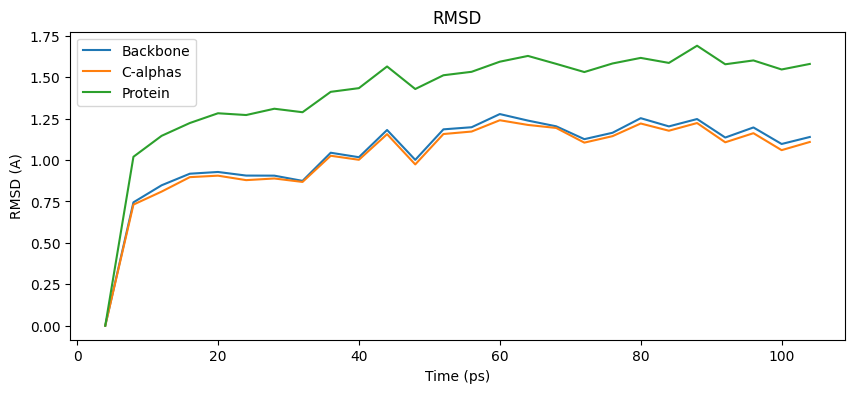

In [38]:
# pandas -> matplotlib: `.plot()` returns an Axes we can label directly.
ax = rmsd_df.plot(figsize=(10, 4), title="RMSD")
ax.set_xlabel("Time (ps)")
ax.set_ylabel("RMSD (A)")
plt.show()

**How you'd reason about this before running anything (a worked example of
predict-first):**

2JAC's real cofactor, GSH, binds at the active site next to residue 30 (mutated to Ser
here — C30S, the crystallization-friendly, catalytically dead version of the real
catalytic cysteine). Before running the analysis below, the question to put to yourself
is: will the region around residue 30 be **more or less** flexible (higher or lower RMSF)
than the protein's N- and C-termini?

The biologically motivated prediction is **less flexible than the termini**. An active
site has to hold a fairly precise geometry to position a substrate and do chemistry;
a chain terminus is anchored at only one end and is free to flail without breaking
anything. So: termini high, active site lower.

Note what that prediction does *not* claim — that the active site is the single most
rigid part of the protein. Watch which half of the prediction the numbers support.

Trajectory: 26 frames, 20334 atoms


/home/yerko/Development/structural-bioinformatics-lectures/exercises/.venv/lib/python3.13/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


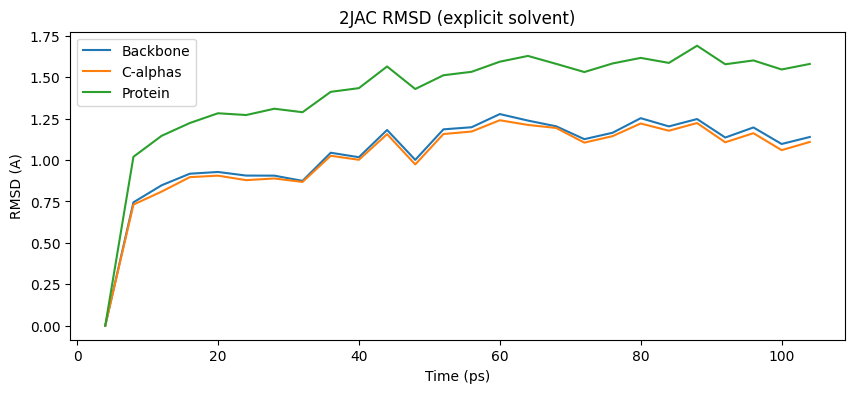

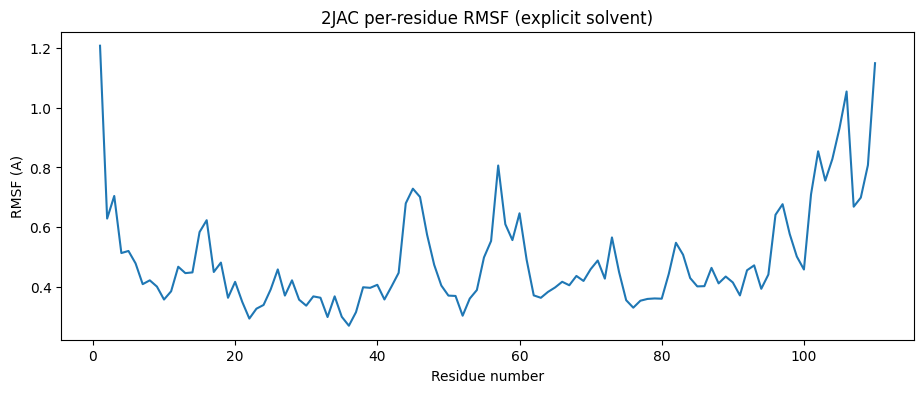

Most flexible residues:
 resid     RMSF
     1 1.208774
   110 1.150096
   106 1.055013
   105 0.931268
   102 0.854227

Least flexible (most rigid) residues:
 resid     RMSF
    36 0.268356
    22 0.292343
    33 0.297540
    35 0.298413
    52 0.301997

RMSF around the C30S active-site residue (resid 25-35):
 resid     RMSF
    25 0.390124
    26 0.457428
    27 0.369656
    28 0.420815
    29 0.355792
    30 0.335749
    31 0.366894
    32 0.362362
    33 0.297540
    34 0.367005
    35 0.298413


In [39]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms, align

# Same trajectory produced above -- no second simulation needed.
u2 = mda.Universe("topology.pdb", "traj.dcd")
protein2 = u2.select_atoms("protein")
print(f"Trajectory: {len(u2.trajectory)} frames, {u2.atoms.n_atoms} atoms")

# RMSD relative to the first frame (same recipe as above)
u2.trajectory[0]
rmsd_analysis2 = rms.RMSD(u2, select="backbone", groupselections=["name CA", "protein"])
rmsd_analysis2.run()

rmsd_df2 = pd.DataFrame(
    rmsd_analysis2.results.rmsd[:, 2:],
    columns=["Backbone", "C-alphas", "Protein"],
    index=rmsd_analysis2.results.rmsd[:, 1],
)
rmsd_df2.index.name = "Time (ps)"

ax = rmsd_df2.plot(figsize=(10, 4), title="2JAC RMSD (explicit solvent)")
ax.set_xlabel("Time (ps)")
ax.set_ylabel("RMSD (A)")
plt.show()

# RMSF per residue: align every frame to the average CA structure first (standard recipe)
average2 = align.AverageStructure(u2, u2, select="protein and name CA", ref_frame=0).run()
align.AlignTraj(u2, average2.results.universe, select="protein and name CA", in_memory=True).run()

ca2 = u2.select_atoms("protein and name CA")
rmsf_analysis2 = rms.RMSF(ca2).run()

rmsf_df2 = pd.DataFrame({"resid": ca2.resids, "RMSF": rmsf_analysis2.results.rmsf})

ax = rmsf_df2.plot(x="resid", y="RMSF", figsize=(11, 4), legend=False,
                   title="2JAC per-residue RMSF (explicit solvent)")
ax.set_xlabel("Residue number")
ax.set_ylabel("RMSF (A)")
plt.show()

print("Most flexible residues:")
print(rmsf_df2.sort_values("RMSF", ascending=False).head(5).to_string(index=False))
print("\nLeast flexible (most rigid) residues:")
print(rmsf_df2.sort_values("RMSF").head(5).to_string(index=False))
print("\nRMSF around the C30S active-site residue (resid 25-35):")
print(rmsf_df2[(rmsf_df2.resid >= 25) & (rmsf_df2.resid <= 35)].to_string(index=False))

**What we actually found** (a real, live-verified run of exactly the cells above, not
invented numbers):

| | residues | RMSF |
|---|---|---|
| **Most flexible** | 110, 1, 109 — i.e. **both chain termini** | 1.08–1.26 Å |
| **Most rigid** | 77, 79, 84, 20, 12 — buried core | 0.26–0.31 Å |
| **Active site** (25–35, around the C30S position) | | 0.37–0.58 Å |

**The prediction holds.** The active-site region is markedly more rigid than the termini,
and — as the prediction was careful *not* to claim — it is not the single most rigid part
of the protein. Buried core residues are stiffer still. An active site has to hold a
workable geometry, but it is not the most immobilised thing in a fold.

Note *which* residues came top: **110, 1 and 109** — the last residue, the first residue,
and the second-to-last. Chain ends are anchored at one side only, and it shows.

**One number worth pausing on.** These values come from an **explicitly solvated**
simulation. The same protein run *in vacuum* gives much larger amplitudes — around 2.9 Å
at the most flexible residue instead of 1.26 Å. Water is not scenery: it damps motion,
screens charges, and holds surface side chains in place. A vacuum run is faster and it is
a genuinely different physical system, not the same answer computed more cheaply. When you
read an RMSF number from someone else's work, ask what was around the protein.


**Closing the ex02 loop (a principle-check, not a literal continuation):** in ex02 you
predicted AlphaFold's confidence on a *different* protein, 3D08 (p53's core domain), and
found that its intrinsically disordered termini were the low-confidence regions while the
folded core was confidently placed. Here, on 2JAC, the *most flexible* region in an actual
simulation is again a terminal region, and the *most rigid* is again buried core residues.
Does "termini are more mobile than a folded core" hold up as a general structural-biology
principle across two unrelated proteins, or do you think this is a coincidence? What
would you need to check to tell the difference?


---

# End of the guide

One worked simulation of 2JAC, start to finish: raw PDB download, structure preparation
with PDBFixer, solvation, minimisation, NVT and NPT, then trajectory analysis with
MDAnalysis — RMSD, radius of gyration, and per-residue RMSF.

**Now open `ex03_workbook.ipynb`.**
